
# Tugas Kelompok 3 - Week 9: Modeling & Implementation
## Bagian 1: Pemilihan Model dan Training (50%)


### 1. Persiapan dan Eksplorasi Data
Dataset yang digunakan: `dataset_baru_CC.csv` (hasil preprocessing dari Tugas Kelompok 1).



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Setting visualisasi
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Baca dataset
df = pd.read_csv('dataset_baru_CC.csv')
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (233953, 31)


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,Amount_scaled,Time_scaled
0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-0.765542,-1.996260
1,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,0.823497,-1.996218
2,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,-0.371407,...,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,0,-0.742403,-1.996218
3,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,-0.099254,...,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,0,-0.711236,-1.996176
4,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,1.249376,...,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,0,0.134284,-1.996113


## Informasi dataset

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 233953 entries, 0 to 233952
Data columns (total 31 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   V1             233953 non-null  float64
 1   V2             233953 non-null  float64
 2   V3             233953 non-null  float64
 3   V4             233953 non-null  float64
 4   V5             233953 non-null  float64
 5   V6             233953 non-null  float64
 6   V7             233953 non-null  float64
 7   V8             233953 non-null  float64
 8   V9             233953 non-null  float64
 9   V10            233953 non-null  float64
 10  V11            233953 non-null  float64
 11  V12            233953 non-null  float64
 12  V13            233953 non-null  float64
 13  V14            233953 non-null  float64
 14  V15            233953 non-null  float64
 15  V16            233953 non-null  float64
 16  V17            233953 non-null  float64
 17  V18            233953 non-null  float64


## 2. Statistik Deskriptif untuk Variabel Numerik
### mean, median, modus, std dev, skewness, kurtosis)

In [3]:
# Pilih kolom numerik
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Kolom numerik:", numeric_cols)

# Fungsi hitung statistik
def descriptive_stats_numeric(df, cols):
    stats_list = []
    for col in cols:
        data = df[col].dropna()
        if len(data) == 0:
            continue
        stats_list.append({
            'Fitur': col,
            'Mean': data.mean(),
            'Median': data.median(),
            'Modus': data.mode().iloc[0] if not data.mode().empty else np.nan,
            'Std Dev': data.std(),
            'Skewness': data.skew(),
            'Kurtosis': data.kurtosis()  # excess kurtosis
        })
    return pd.DataFrame(stats_list)

df_stats = descriptive_stats_numeric(df, numeric_cols)
df_stats

Kolom numerik: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Class', 'Amount_scaled', 'Time_scaled']


,Fitur,Mean,Median,Modus,Std Dev,Skewness,Kurtosis
0,V1,0.112824,0.026751,1.245674,1.781879,-2.290441,17.508843
1,V2,0.291566,0.212002,-0.326668,1.256691,-1.291769,49.530089
2,V3,0.062012,0.224158,-2.752041,1.463011,-2.097029,25.069521
3,V4,-0.015365,-0.021852,-0.842316,1.388401,0.589675,2.092028
4,V5,0.148598,0.049299,-0.562777,1.194932,0.948373,32.658250
5,V6,-0.075034,-0.337747,-1.011073,1.262730,1.184025,6.135483
6,V7,-0.079471,0.022890,-0.432126,1.024856,-5.022862,95.232044
7,V8,0.023928,0.027044,-0.160211,1.145776,-6.995100,142.464470
8,V9,0.014871,-0.040358,0.170362,1.072989,0.584658,3.901665
9,V10,0.022204,-0.088337,-0.075186,1.078051,1.469649,31.409130


## 3. Korelasi Antar Fitur
### (hitung matriks korelasi dan tampilkan heatmap)

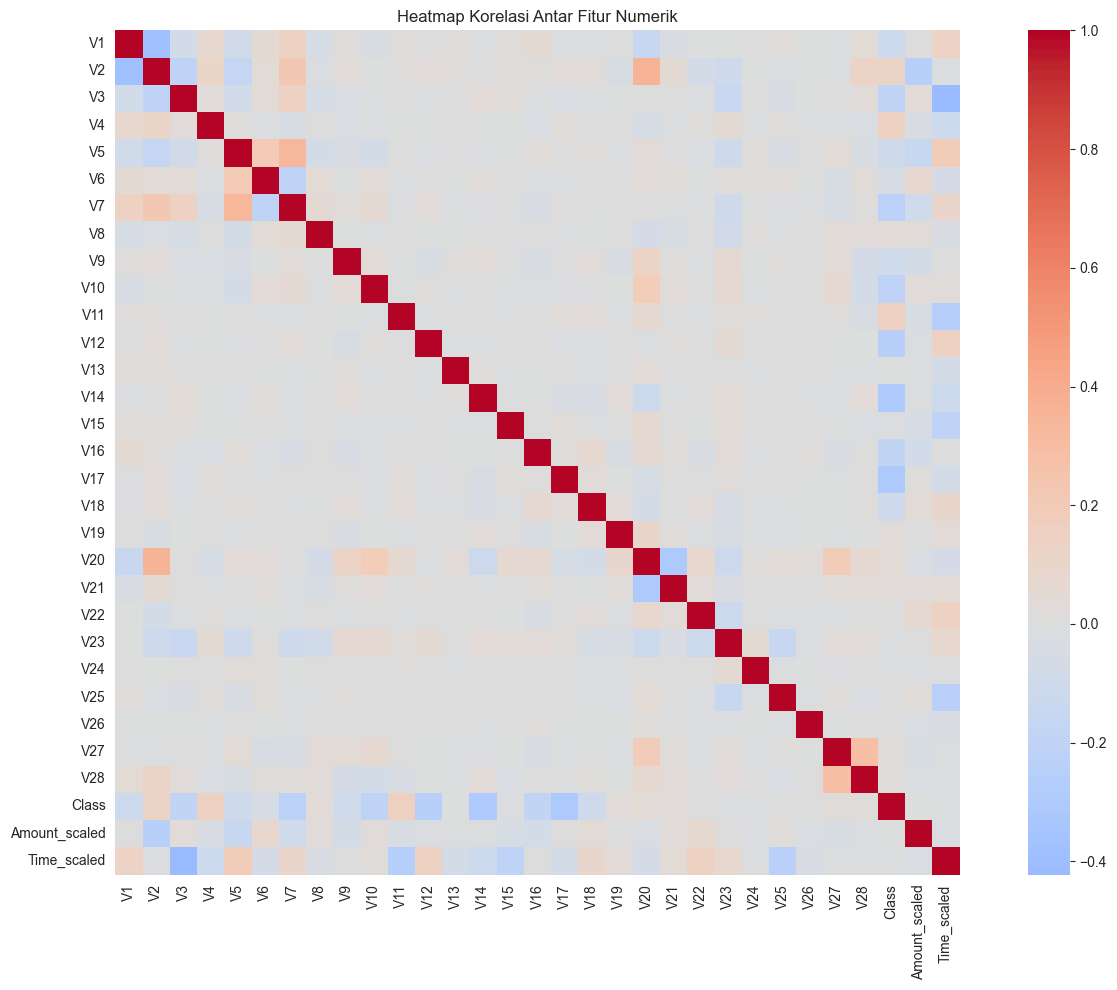

10 pasang fitur dengan korelasi tertinggi:
V20  V2     0.362068
V2   V20    0.362068
V7   V5     0.337627
V5   V7     0.337627
V27  V28    0.283969
V28  V27    0.283969
V2   V7     0.217700
V7   V2     0.217700
V6   V5     0.209081
V5   V6     0.209081
dtype: float64


In [4]:
# Matriks korelasi
corr_matrix = df[numeric_cols].corr()

# Heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, square=True)
plt.title('Heatmap Korelasi Antar Fitur Numerik')
plt.tight_layout()
plt.show()

# 10 pasang fitur dengan korelasi tertinggi (selain diagonal)
corr_pairs = corr_matrix.unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs != 1]
corr_pairs = corr_pairs.dropna()
print("10 pasang fitur dengan korelasi tertinggi:")
print(corr_pairs.head(10))

## 4. Identifikasi Outlier

### 1. Boxplot untuk setiap fitur numerik

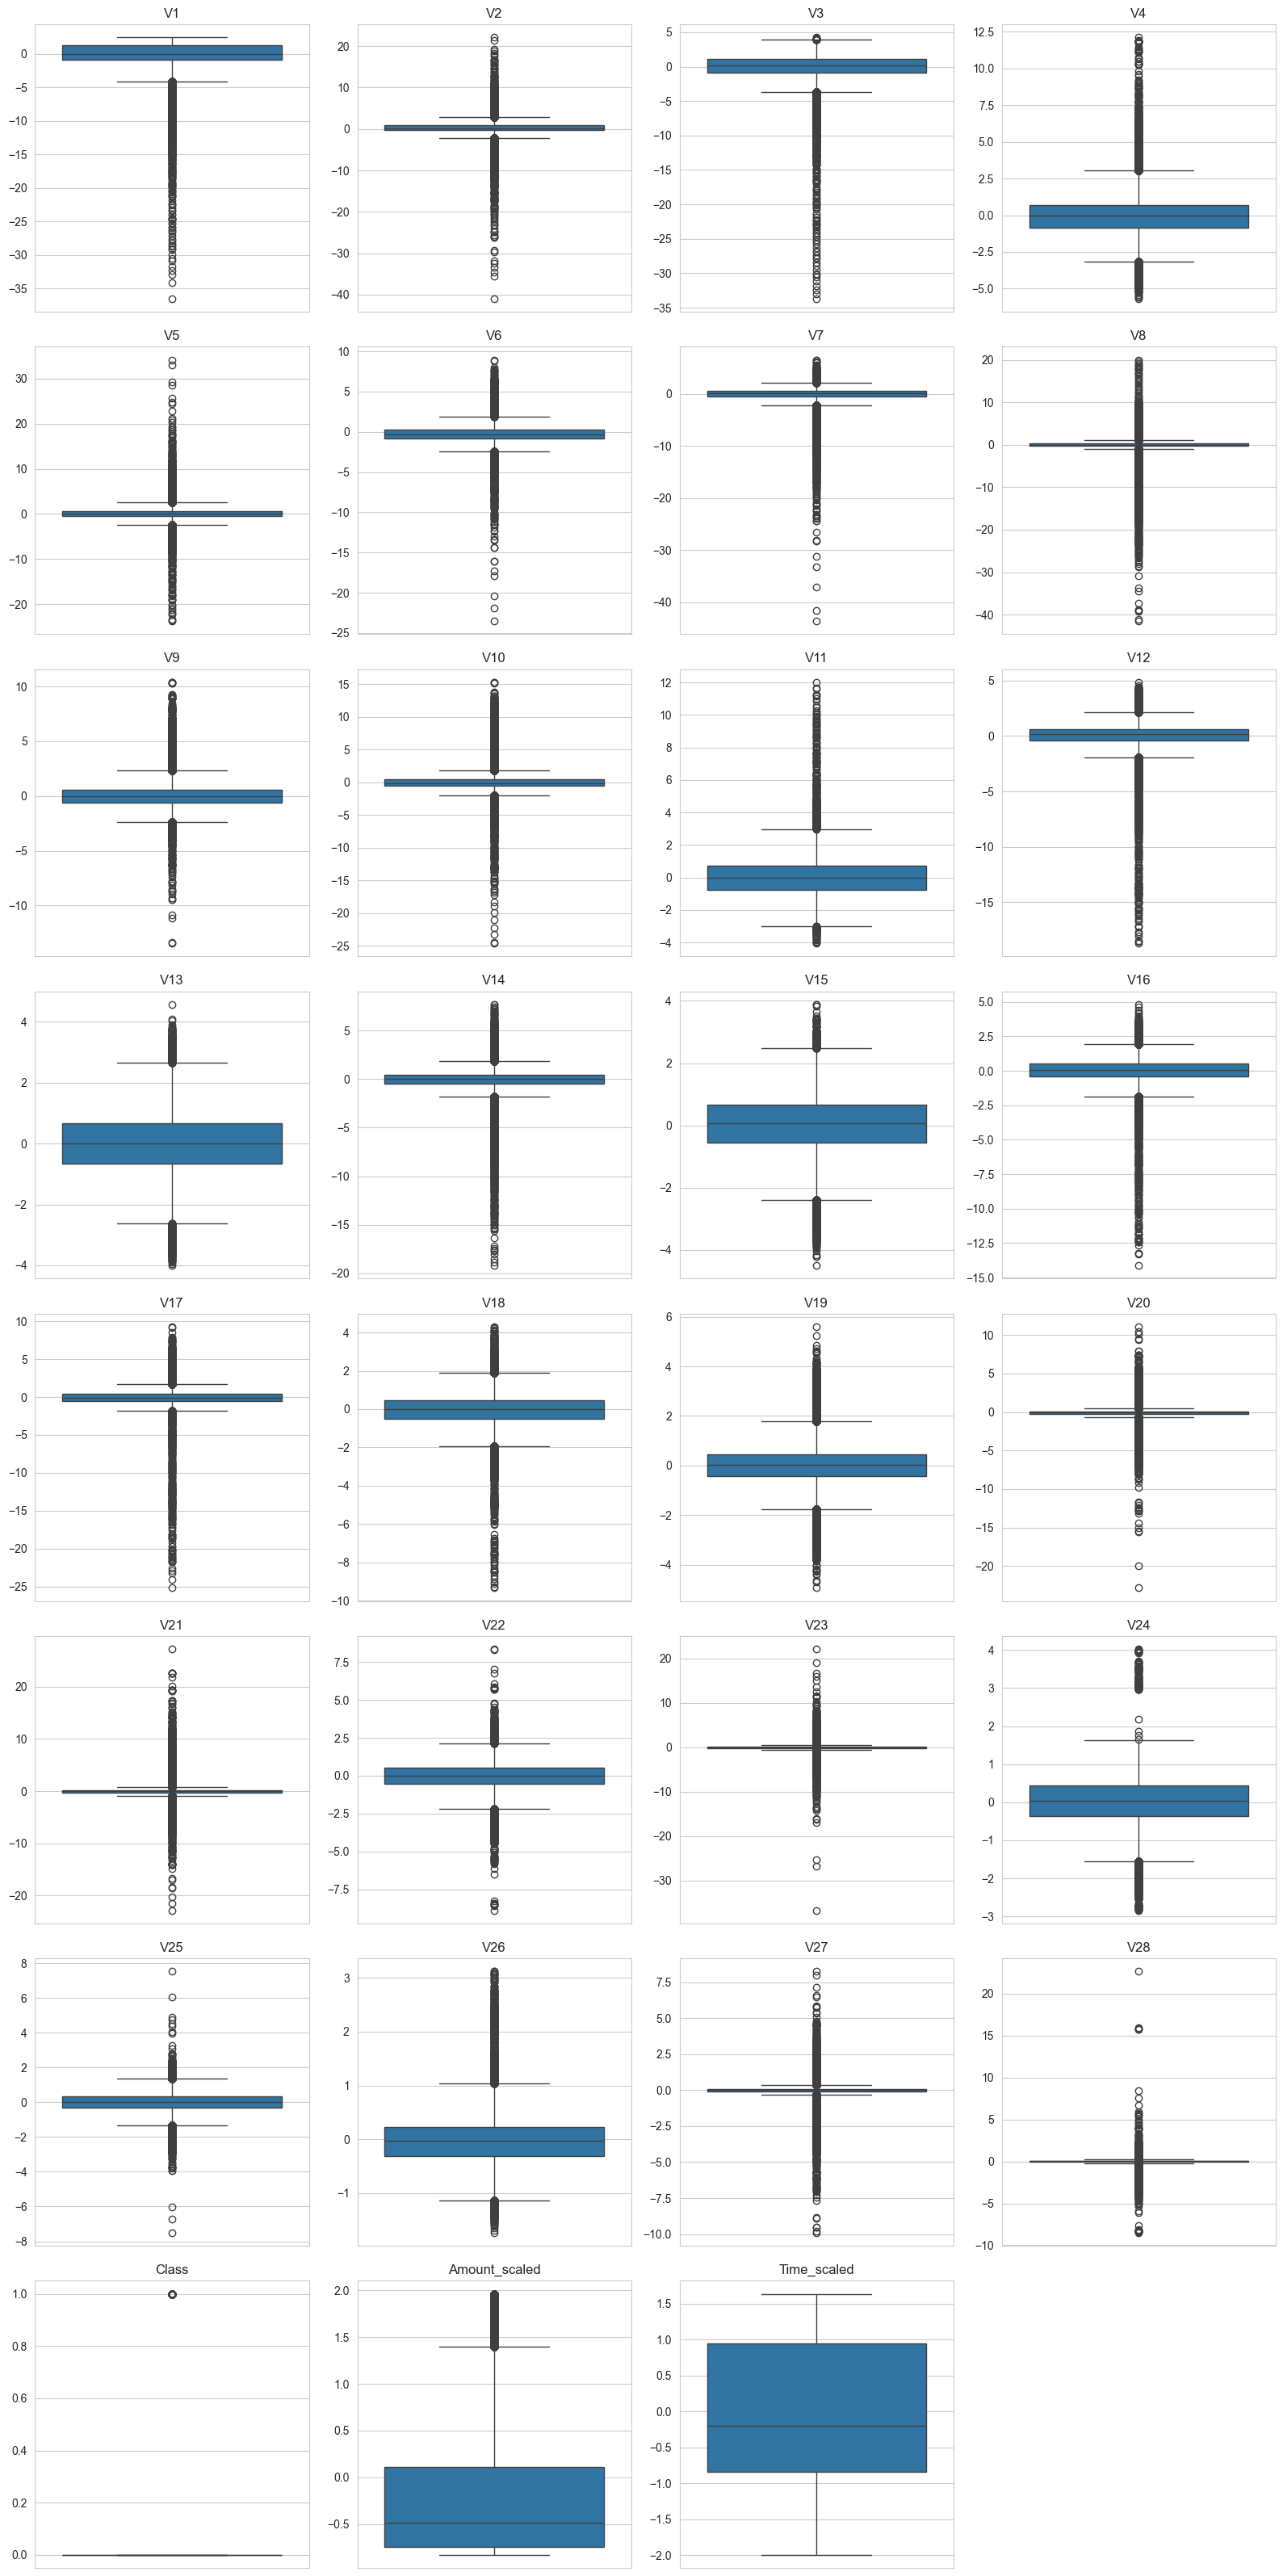

In [5]:
n_cols = len(numeric_cols)
n_rows = (n_cols + 3) // 4
fig, axes = plt.subplots(n_rows, 4, figsize=(16, 4*n_rows))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_ylabel('')
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

### 2. Z-score untuk mendeteksi outlier

In [6]:
# Isi NA dengan mean sementara (jika ada)
df_num = df[numeric_cols].fillna(df[numeric_cols].mean())
z_scores = np.abs(stats.zscore(df_num))
outliers_z = (z_scores > 3).any(axis=1)
print(f"Jumlah baris dengan setidaknya satu outlier (|Z|>3): {outliers_z.sum()}")
print(f"Persentase: {outliers_z.sum()/len(df)*100:.2f}%")

Jumlah baris dengan setidaknya satu outlier (|Z|>3): 33072
Persentase: 14.14%


## 5. Visualisasi Data
### 1.Histogram distribusi fitur numerik

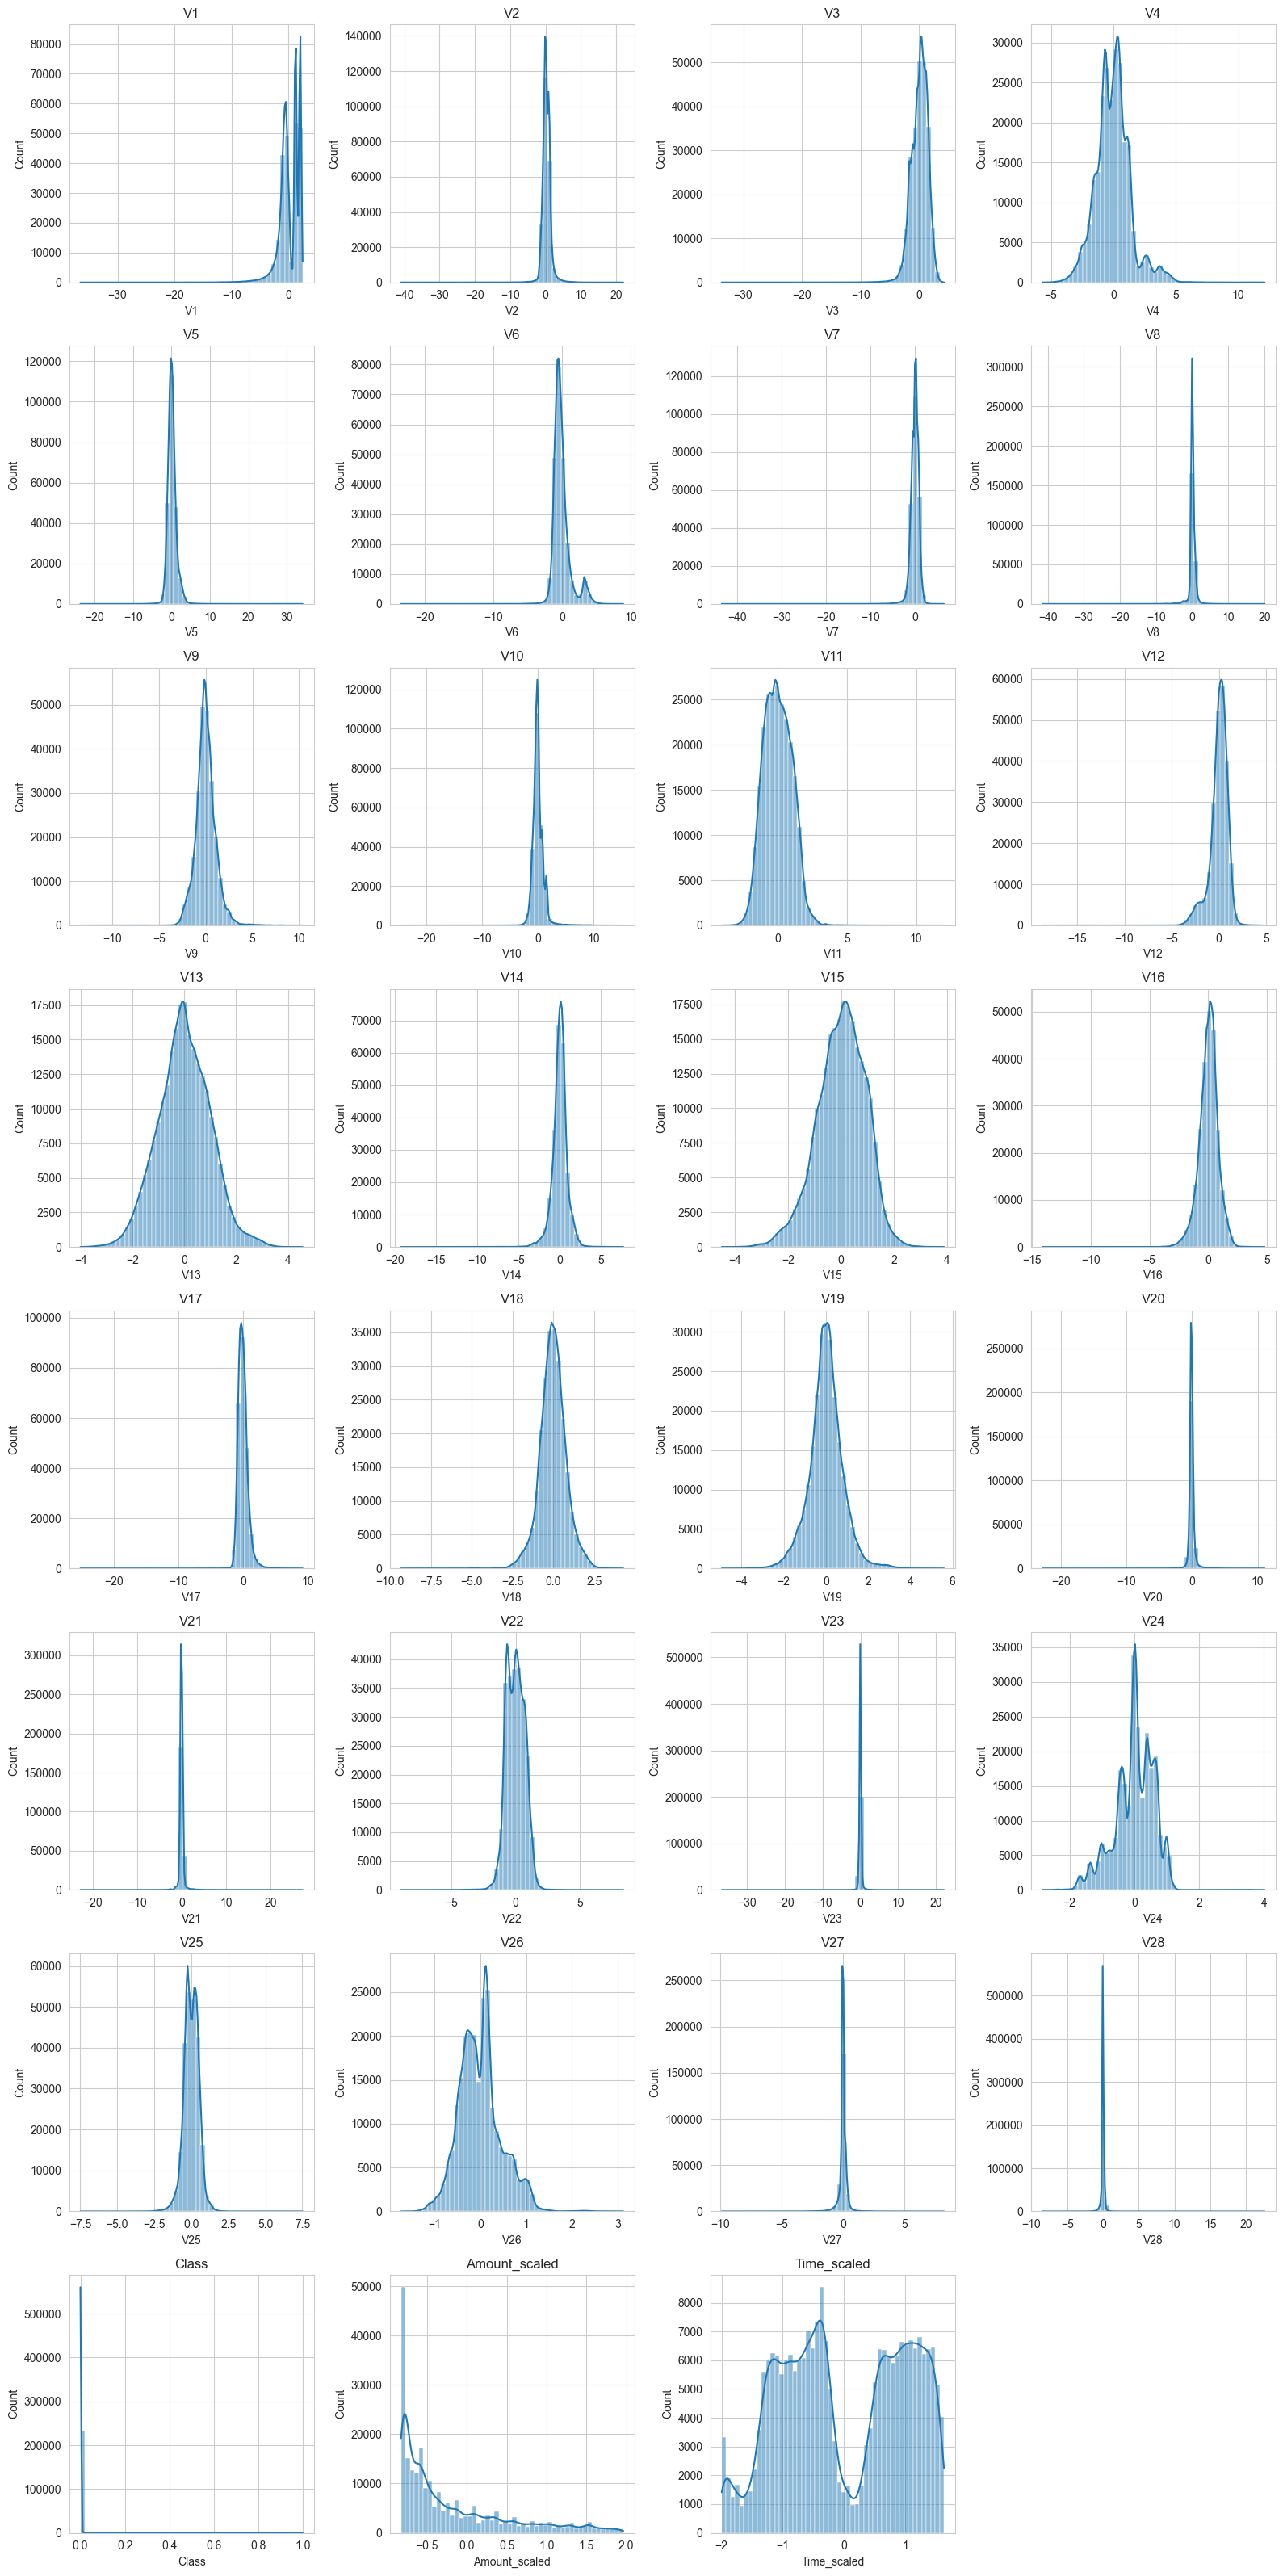

In [7]:
fig, axes = plt.subplots(n_rows, 4, figsize=(16, 4*n_rows))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], bins=50)
    axes[i].set_title(col)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

### 2. Pair Plot (untuk fitur terpilih, misal 5 fitur)

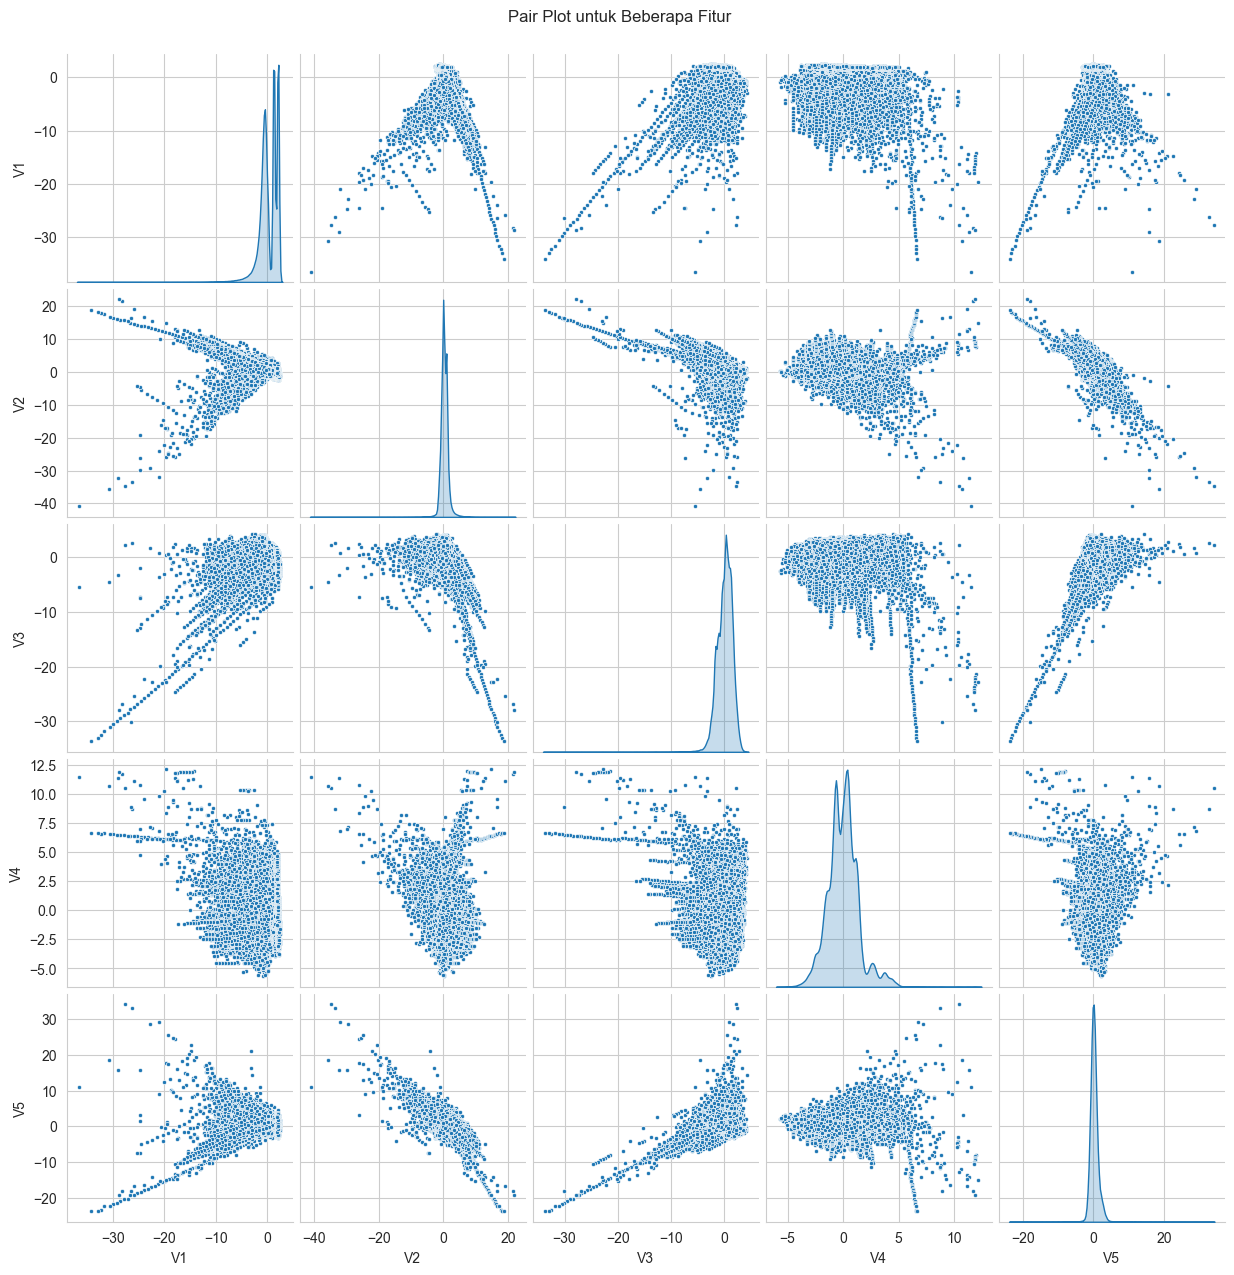

In [8]:
# Pilih 5 fitur dengan varians terbesar atau berdasarkan korelasi
if len(numeric_cols) > 5:
    # Ambil 5 fitur pertama (atau bisa pakai yang korelasinya tinggi)
    top_features = numeric_cols[:5]  # sesuaikan
else:
    top_features = numeric_cols
sns.pairplot(df[top_features], diag_kind='kde', markers='.', height=2.5)
plt.suptitle('Pair Plot untuk Beberapa Fitur', y=1.02)
plt.show()

### 3. Scatter Plot khusus

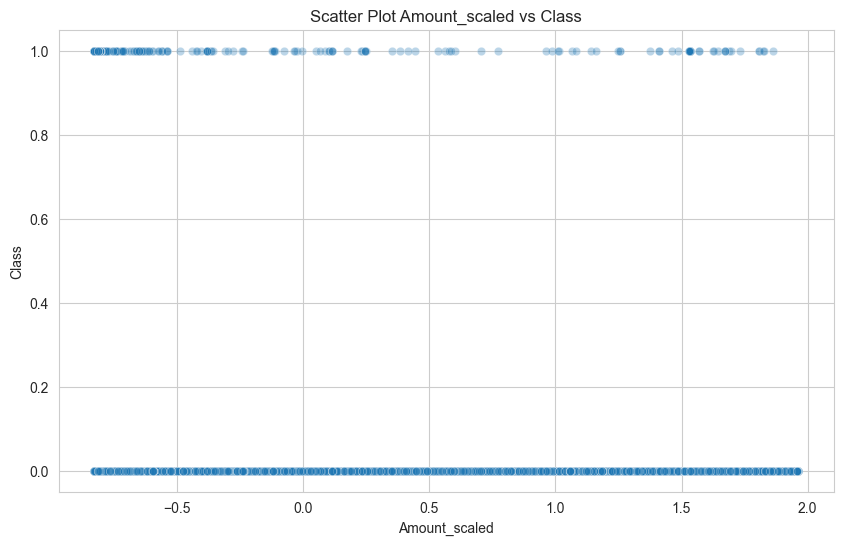

In [12]:
if 'Amount_scaled' in df.columns and 'Class' in df.columns:
    plt.figure(figsize=(10,6))
    sns.scatterplot(data=df, x='Amount_scaled', y='Class', alpha=0.3)
    plt.title('Scatter Plot Amount_scaled vs Class')
    plt.show()

### **1. Gambaran Umum Data**

*   **Ukuran Dataset**: Terdapat **233.953** transaksi dan **31** kolom.
*   **Struktur Data**: Terdiri dari 28 kolom hasil transformasi PCA (`V1` hingga `V28`), kolom `Class` (target: 0 = transaksi normal, 1 = fraud), serta dua kolom tambahan `Amount` dan `Time` yang telah di-*scaling* (`Amount_scaled`, `Time_scaled`).
*   **Target**: Data ini sangat **tidak seimbang** (*imbalanced*). Kelas `Class = 0` (normal) adalah mayoritas, sementara kelas `Class = 1` (fraud) sangat minoritas (hanya sekitar **0.15%** dari total data). Ini adalah karakteristik umum dalam deteksi fraud.

### **2. Distribusi Data dan Statistik Deskriptif**

*   **Fitur PCA (V1 - V28)**:
    *   **Mean dan Median**: Nilai mean dan median untuk mayoritas fitur PCA mendekati **0**.
    *   **Standar Deviasi**: Nilai standar deviasi adalah sekitar **1**, yang mengindikasikan bahwa data telah dinormalisasi/di-*scale* dengan baik.
    *   **Kurtosis**: Nilai kurtosis yang sangat tinggi (misal, `V28` = 661) dan skewness yang jauh dari 0 (positif atau negatif) mengindikasikan adanya **outlier** atau distribusi yang sangat ekor (ekor *heavy-tailed*), yang umum terjadi pada data hasil PCA.

*   **Fitur `Class`**:
    *   Mean yang sangat kecil (0.00156) mengonfirmasi ketidakseimbangan kelas yang ekstrem.

*   **Fitur `Amount_scaled`**:
    *   Sebaran data tidak simetris (skewness positif), yang berarti ada transaksi dengan nilai nominal yang sangat besar (outlier) yang mempengaruhi distribusi.

### **3. Korelasi Antar Fitur**

*   Matriks korelasi (heatmap) menunjukkan bahwa mayoritas fitur PCA (`V1` - `V28`) memiliki korelasi yang **sangat lemah** satu sama lain (kebanyakan mendekati 0). Ini adalah tujuan dari PCA itu sendiri, yaitu untuk menciptakan fitur-fitur baru yang tidak saling berkorelasi.
*   Meskipun demikian, beberapa pasang fitur PCA masih menunjukkan korelasi yang relatif lebih tinggi, seperti:
    *   `V20` dan `V2` (0.362)
    *   `V5` dan `V7` (0.337)
    *   `V27` dan `V28` (0.283)
    *   Korelasi ini, meskipun positif, masih tergolong **sedang** dan tidak terlalu kuat. Ini mungkin menyisakan sedikit redundansi informasi.

### **4. Identifikasi Outlier**

*   **Metode Boxplot**: Pada grafik boxplot setiap fitur PCA (`V1` hingga `V28`), terlihat banyak titik-titik di luar *whisker* (batas atas/bawah). Ini menegaskan keberadaan **outlier** pada setiap fitur.
*   **Metode Z-Score**:
    *   Dengan ambang batas `|Z| > 3`, ditemukan bahwa sekitar **14.14%** dari seluruh baris data (sekitar 33.072 baris) memiliki setidaknya satu fitur yang terindikasi sebagai outlier.
    *   Jumlah ini cukup besar. Dalam konteks deteksi fraud, **outlier tidak bisa serta-merta dihapus**. Transaksi fraud sering kali justru merupakan outlier. Kehadiran outlier ini mungkin merupakan sinyal penting untuk diidentifikasi oleh model.

### **5. Visualisasi Data (Histogram & Pair Plot)**

*   **Histogram**:
    *   Mayoritas fitur PCA (`V1` - `V28`) memiliki distribusi yang **simetris** dan menyerupai distribusi normal (berbentuk lonceng), yang dihasilkan dari proses PCA dan penskalaan. Namun, beberapa fitur (seperti `V7`, `V8`) menunjukkan distribusi yang lebih lonjong di pusatnya dan ekor yang lebih panjang.
*   **Pair Plot**:
    *   Grafik untuk fitur-fitur terpilih menunjukkan bahwa titik-titik data dari kelas mayoritas (biru) dan kelas minoritas (merah) **sangat sulit dipisahkan secara linear** hanya dengan melihat pasangan fitur PCA.
    *   Ini mengindikasikan bahwa **model non-linear** (seperti Random Forest, XGBoost, atau Neural Network) kemungkinan akan bekerja lebih baik dibandingkan model linear sederhana (seperti Regresi Logistik murni).

